# Final test results — publication figures

This notebook turns the frozen one-shot test artifacts into publication-ready figures. It **does not train models, load prediction data, or rerun the test evaluation**.

The figures are deliberately separated into:

- **Main results:** the primary non-inferiority result, client heterogeneity, and training-seed robustness.
- **Secondary results:** skill relative to persistence and the bootstrap sampling distribution.

Every figure is exported as vector PDF for the paper and as a 300-DPI PNG for previewing.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Work whether the notebook kernel starts in the repository root or notebooks/.
ROOT = Path.cwd().resolve()
if not (ROOT / "results").exists():
    ROOT = ROOT.parent
if not (ROOT / "results").exists():
    raise FileNotFoundError("Run this notebook from the repository or notebooks directory.")

RESULTS_DIR = ROOT / "results"
OUTPUT_DIR = RESULTS_DIR / "graph" / "test"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Okabe–Ito-inspired colors remain distinguishable for common color-vision deficiencies.
CENTRAL = "#0072B2"
FEDPROX = "#D55E00"
CI_COLOR = "#009E73"
NEUTRAL = "#4D4D4D"
LIGHT_GREY = "#D0D0D0"
MARGIN_COLOR = "#CC79A7"

sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9.5,
    "axes.titleweight": "semibold",
    "axes.linewidth": 0.8,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8.5,
    "legend.frameon": False,
    "lines.linewidth": 1.7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def save_figure(fig, stem):
    """Save an editable vector PDF and a high-resolution preview PNG."""
    pdf_path = OUTPUT_DIR / f"{stem}.pdf"
    png_path = OUTPUT_DIR / f"{stem}.png"
    fig.savefig(pdf_path, facecolor="white")
    fig.savefig(png_path, dpi=300, facecolor="white")
    print(f"saved: {pdf_path.relative_to(ROOT)}")
    print(f"saved: {png_path.relative_to(ROOT)}")

In [2]:
summary = pd.read_csv(RESULTS_DIR / "test_evaluation_summary.csv")
by_seed = pd.read_csv(RESULTS_DIR / "test_evaluation_by_seed.csv")
detail = pd.read_csv(RESULTS_DIR / "test_evaluation_detail.csv")
bootstrap = pd.read_csv(RESULTS_DIR / "test_evaluation_bootstrap.csv")

expected = {
    "summary": {"observed_macro_gap", "ci_lower", "ci_upper", "noninferiority_margin"},
    "by_seed": {"seed", "central_macro_mae", "fedprox_macro_mae", "macro_gap_fedprox_minus_central"},
    "detail": {"seed", "client", "method", "mae", "rmse", "skill"},
    "bootstrap": {"repetition", "macro_gap_fedprox_minus_central"},
}
for name, frame in {"summary": summary, "by_seed": by_seed, "detail": detail, "bootstrap": bootstrap}.items():
    missing = expected[name] - set(frame.columns)
    if missing:
        raise ValueError(f"{name} is missing columns: {sorted(missing)}")

if len(summary) != 1:
    raise ValueError("The frozen primary evaluation must have exactly one summary row.")
if len(by_seed) != 5 or sorted(by_seed["seed"].tolist()) != list(range(5)):
    raise ValueError("Expected exactly the frozen training seeds 0–4.")
if len(bootstrap) != 10_000:
    raise ValueError("Expected exactly 10,000 frozen bootstrap repetitions.")

summary.round(6)

,n_calendar_days,n_clients,n_training_seeds,bootstrap_repetitions,bootstrap_seed,confidence_level,central_macro_mae_mean,fedprox_macro_mae_mean,observed_macro_gap,ci_lower,ci_upper,noninferiority_margin,noninferiority_passes
0,49,7,5,10000,0,0.95,0.133405,0.128397,-0.005008,-0.009926,-0.000537,0.005,True


---

# Main results

These figures should appear first because they directly address the primary research question and show whether the conclusion is stable across clients and training seeds.

## Figure 1 — Primary non-inferiority result

The large diamond is the observed mean gap. Its horizontal line is the paired complete-day bootstrap 95% confidence interval. Small circles show seed-specific observed gaps; they are not confidence-interval endpoints. Lower values favor FedProx.

findfont: Failed to find font weight semibold, now using 700.


saved: results/graph/test/fig1_noninferiority_ci.pdf
saved: results/graph/test/fig1_noninferiority_ci.png


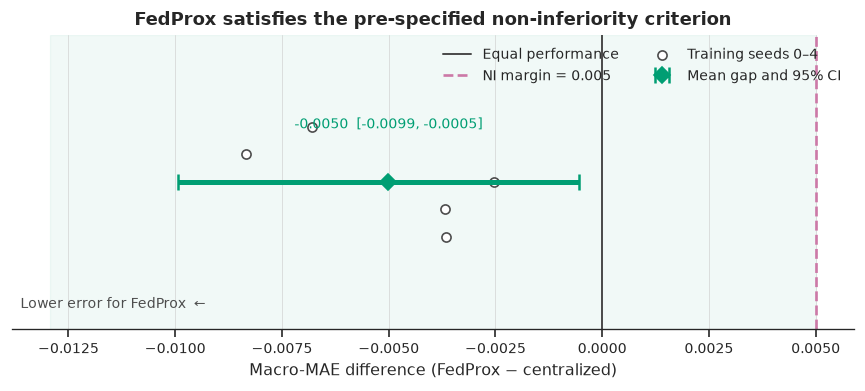

In [3]:
row = summary.iloc[0]
observed = row["observed_macro_gap"]
lower = row["ci_lower"]
upper = row["ci_upper"]
margin = row["noninferiority_margin"]
seed_gaps = by_seed["macro_gap_fedprox_minus_central"].to_numpy()
seed_y = np.linspace(-0.18, 0.18, len(seed_gaps))

fig, ax = plt.subplots(figsize=(7.1, 3.15), constrained_layout=True)
ax.axvspan(min(lower, seed_gaps.min()) - 0.003, margin, color=CI_COLOR, alpha=0.055, zorder=0)
ax.axvline(0, color=NEUTRAL, linewidth=1.2, label="Equal performance")
ax.axvline(margin, color=MARGIN_COLOR, linewidth=1.6, linestyle="--", label="NI margin = 0.005")
ax.scatter(seed_gaps, seed_y, s=30, facecolor="white", edgecolor=NEUTRAL, linewidth=1, zorder=3, label="Training seeds 0–4")
ax.errorbar(
    observed, 0, xerr=[[observed - lower], [upper - observed]],
    fmt="D", markersize=7, color=CI_COLOR, ecolor=CI_COLOR,
    elinewidth=3, capsize=5, capthick=1.5, zorder=4, label="Mean gap and 95% CI",
)
ax.annotate(
    f"{observed:.4f}  [{lower:.4f}, {upper:.4f}]",
    xy=(observed, 0), xytext=(0, 30), textcoords="offset points",
    ha="center", va="bottom", fontsize=8.5, color=CI_COLOR,
)
ax.set(
    title="FedProx satisfies the pre-specified non-inferiority criterion",
    xlabel="Macro-MAE difference (FedProx − centralized)",
    yticks=[], ylim=(-0.48, 0.48),
)
ax.text(0.01, 0.07, "Lower error for FedProx  ←", transform=ax.transAxes, color=NEUTRAL, fontsize=8.5)
ax.legend(loc="upper right", ncols=2)
ax.grid(axis="x", color=LIGHT_GREY, linewidth=0.6, alpha=0.65)
sns.despine(ax=ax, left=True)
save_figure(fig, "fig1_noninferiority_ci")
plt.show()

## Figure 2 — Client-level paired MAE

Large endpoints are five-seed mean MAEs, joined within each client. Faint points retain the individual training-seed results. This figure reveals whether the macro-average is broadly representative or driven by a small number of stations.

saved: results/graph/test/fig2_client_mae.pdf
saved: results/graph/test/fig2_client_mae.png


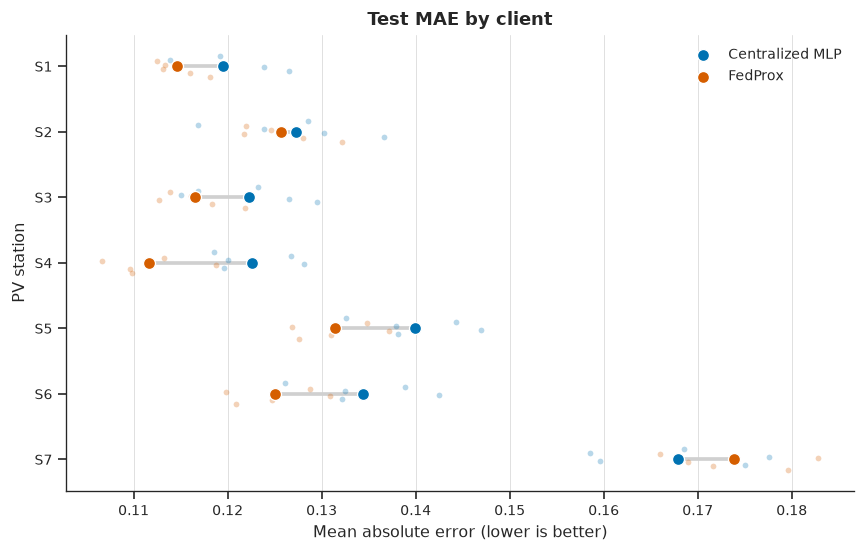

In [4]:
client_order = sorted(detail["client"].unique(), key=lambda value: int(value[1:]))
client_mean = detail.groupby(["client", "method"], as_index=False)["mae"].mean()
client_wide = client_mean.pivot(index="client", columns="method", values="mae").loc[client_order]
y_positions = np.arange(len(client_order))

fig, ax = plt.subplots(figsize=(7.1, 4.5), constrained_layout=True)
for y, client in zip(y_positions, client_order):
    left = client_wide.loc[client, "central_mlp"]
    right = client_wide.loc[client, "fedprox_e1"]
    ax.plot([left, right], [y, y], color=LIGHT_GREY, linewidth=2.2, zorder=1)

seed_jitter = np.linspace(-0.12, 0.12, 5)
for method, color, offset in [("central_mlp", CENTRAL, -0.04), ("fedprox_e1", FEDPROX, 0.04)]:
    subset = detail[detail["method"] == method]
    for client_idx, client in enumerate(client_order):
        values = subset[subset["client"] == client].sort_values("seed")["mae"]
        ax.scatter(values, client_idx + seed_jitter + offset, s=12, color=color, alpha=0.28, linewidth=0, zorder=2)

ax.scatter(client_wide["central_mlp"], y_positions, s=52, color=CENTRAL, edgecolor="white", linewidth=0.8, label="Centralized MLP", zorder=3)
ax.scatter(client_wide["fedprox_e1"], y_positions, s=52, color=FEDPROX, edgecolor="white", linewidth=0.8, label="FedProx", zorder=3)
ax.set(
    title="Test MAE by client", xlabel="Mean absolute error (lower is better)",
    ylabel="PV station", yticks=y_positions, yticklabels=client_order,
)
ax.invert_yaxis()
ax.grid(axis="x", color=LIGHT_GREY, linewidth=0.6, alpha=0.65)
ax.legend(loc="best")
sns.despine(ax=ax)
save_figure(fig, "fig2_client_mae")
plt.show()

## Figure 3 — Robustness across training seeds

Each line follows one training method across the five frozen seeds. The observations are paired by seed; they should not be interpreted as independent test datasets.

saved: results/graph/test/fig3_seed_robustness.pdf
saved: results/graph/test/fig3_seed_robustness.png


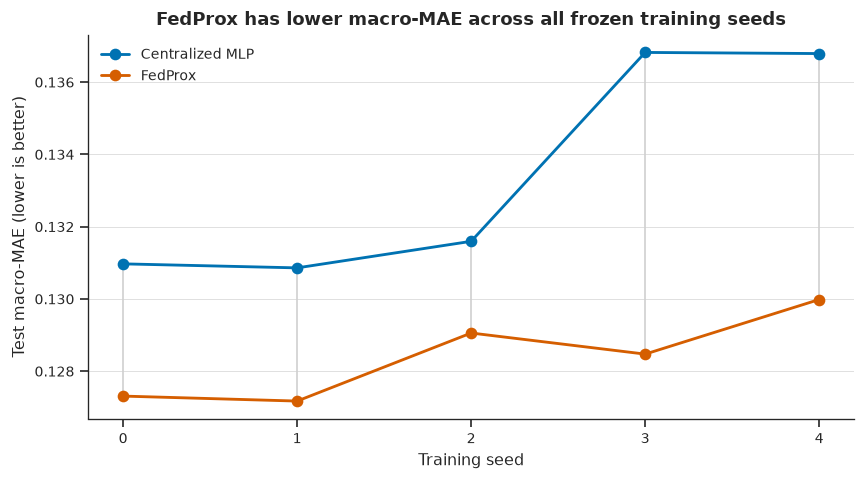

In [5]:
fig, ax = plt.subplots(figsize=(7.1, 3.9), constrained_layout=True)
ax.plot(by_seed["seed"], by_seed["central_macro_mae"], marker="o", markersize=6, color=CENTRAL, label="Centralized MLP")
ax.plot(by_seed["seed"], by_seed["fedprox_macro_mae"], marker="o", markersize=6, color=FEDPROX, label="FedProx")
for _, seed_row in by_seed.iterrows():
    ax.plot(
        [seed_row["seed"], seed_row["seed"]],
        [seed_row["fedprox_macro_mae"], seed_row["central_macro_mae"]],
        color=LIGHT_GREY, linewidth=1, zorder=0,
    )
ax.set(
    title="FedProx has lower macro-MAE across all frozen training seeds",
    xlabel="Training seed", ylabel="Test macro-MAE (lower is better)",
    xticks=by_seed["seed"],
)
ax.grid(axis="y", color=LIGHT_GREY, linewidth=0.6, alpha=0.65)
ax.legend(loc="best")
sns.despine(ax=ax)
save_figure(fig, "fig3_seed_robustness")
plt.show()

---

# Secondary results

These figures add context without replacing the pre-specified primary decision. Skill evaluates the learned methods against persistence; the bootstrap distribution makes the uncertainty calculation visible.

## Figure 4 — Skill relative to persistence

Skill greater than zero means the learned model has lower MAE than same-hour-yesterday persistence. Large points are five-seed client means; faint points are individual seeds.

saved: results/graph/test/fig4_client_skill.pdf
saved: results/graph/test/fig4_client_skill.png


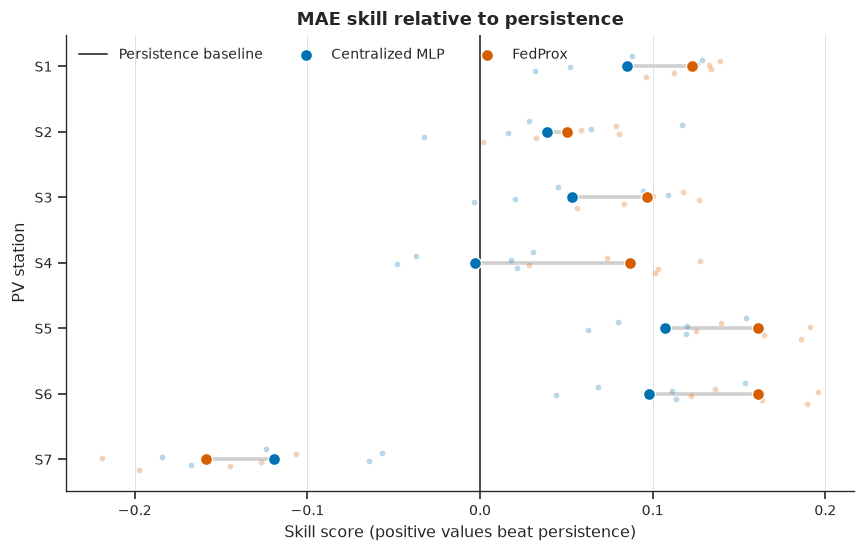

In [6]:
skill_mean = detail.groupby(["client", "method"], as_index=False)["skill"].mean()
skill_wide = skill_mean.pivot(index="client", columns="method", values="skill").loc[client_order]

fig, ax = plt.subplots(figsize=(7.1, 4.5), constrained_layout=True)
ax.axvline(0, color=NEUTRAL, linewidth=1.2, label="Persistence baseline")
for y, client in zip(y_positions, client_order):
    ax.plot(
        [skill_wide.loc[client, "central_mlp"], skill_wide.loc[client, "fedprox_e1"]],
        [y, y], color=LIGHT_GREY, linewidth=2.2, zorder=1,
    )
for method, color, offset in [("central_mlp", CENTRAL, -0.04), ("fedprox_e1", FEDPROX, 0.04)]:
    subset = detail[detail["method"] == method]
    for client_idx, client in enumerate(client_order):
        values = subset[subset["client"] == client].sort_values("seed")["skill"]
        ax.scatter(values, client_idx + seed_jitter + offset, s=12, color=color, alpha=0.28, linewidth=0, zorder=2)
ax.scatter(skill_wide["central_mlp"], y_positions, s=52, color=CENTRAL, edgecolor="white", linewidth=0.8, label="Centralized MLP", zorder=3)
ax.scatter(skill_wide["fedprox_e1"], y_positions, s=52, color=FEDPROX, edgecolor="white", linewidth=0.8, label="FedProx", zorder=3)
ax.set(
    title="MAE skill relative to persistence",
    xlabel="Skill score (positive values beat persistence)",
    ylabel="PV station", yticks=y_positions, yticklabels=client_order,
)
ax.invert_yaxis()
ax.grid(axis="x", color=LIGHT_GREY, linewidth=0.6, alpha=0.65)
ax.legend(loc="best", ncols=3)
sns.despine(ax=ax)
save_figure(fig, "fig4_client_skill")
plt.show()

## Figure 5 — Bootstrap distribution

This methodological figure shows the 10,000 paired complete-day bootstrap gaps. The shaded band is the central 95% of the empirical distribution.

saved: results/graph/test/fig5_bootstrap_distribution.pdf
saved: results/graph/test/fig5_bootstrap_distribution.png


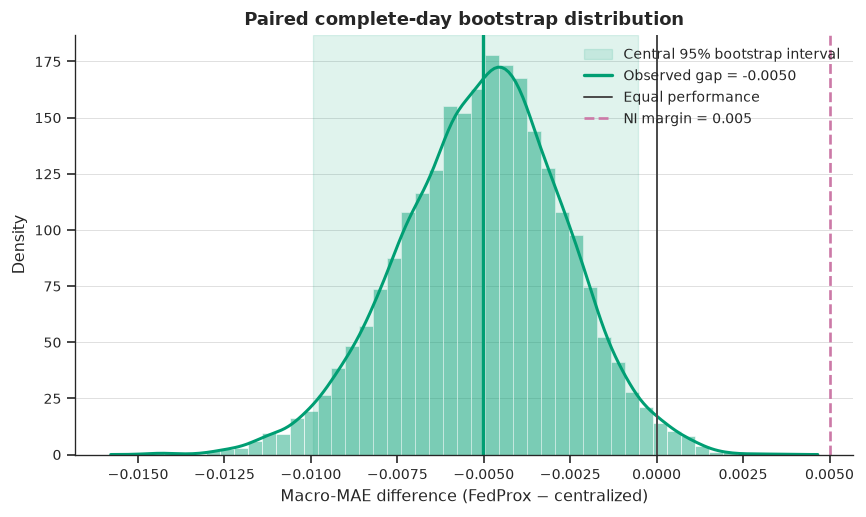

In [7]:
gaps = bootstrap["macro_gap_fedprox_minus_central"]
fig, ax = plt.subplots(figsize=(7.1, 4.2), constrained_layout=True)
sns.histplot(gaps, bins=45, stat="density", color=CI_COLOR, alpha=0.45, edgecolor="white", linewidth=0.35, ax=ax)
sns.kdeplot(gaps, color=CI_COLOR, linewidth=1.8, ax=ax)
ax.axvspan(lower, upper, color=CI_COLOR, alpha=0.12, label="Central 95% bootstrap interval")
ax.axvline(observed, color=CI_COLOR, linewidth=2, label=f"Observed gap = {observed:.4f}")
ax.axvline(0, color=NEUTRAL, linewidth=1.2, label="Equal performance")
ax.axvline(margin, color=MARGIN_COLOR, linewidth=1.6, linestyle="--", label="NI margin = 0.005")
ax.set(
    title="Paired complete-day bootstrap distribution",
    xlabel="Macro-MAE difference (FedProx − centralized)",
    ylabel="Density",
)
ax.grid(axis="y", color=LIGHT_GREY, linewidth=0.6, alpha=0.65)
ax.legend(loc="upper right")
sns.despine(ax=ax)
save_figure(fig, "fig5_bootstrap_distribution")
plt.show()

---

# Suggested paper captions

**Figure 1. Primary non-inferiority comparison.** Difference calculated as FedProx minus centralized macro-MAE and averaged across training seeds 0–4. The horizontal interval is the two-sided 95% paired complete-day bootstrap confidence interval from 10,000 repetitions. Negative values favor FedProx; the dashed line marks the pre-specified non-inferiority margin of 0.005.

**Figure 2. Client-level test MAE.** Large points show mean test MAE across training seeds 0–4, with methods joined within each PV station. Faint points show individual seed results. Lower values indicate better performance.

**Figure 3. Training-seed robustness.** Test macro-MAE for the centralized MLP and FedProx across the five frozen training seeds. Vertical connectors emphasize the paired comparison within each seed.

**Figure 4. Skill relative to persistence.** Client-level MAE skill against same-hour-yesterday persistence, averaged across training seeds 0–4. Positive values indicate lower MAE than persistence; faint points show individual seed results.

**Figure 5. Bootstrap sampling distribution.** Empirical distribution of 10,000 seed-averaged FedProx-minus-centralized macro-MAE gaps obtained by paired resampling of complete calendar dates. The shaded region is the central 95% percentile interval.